Code for the two-compartment model for the intravenous dosage of azacitidine 
- Model both 50 and 75 doses to pick the right or accurate one
- X-axis (time = hours), Y-axis (blast cells count) 

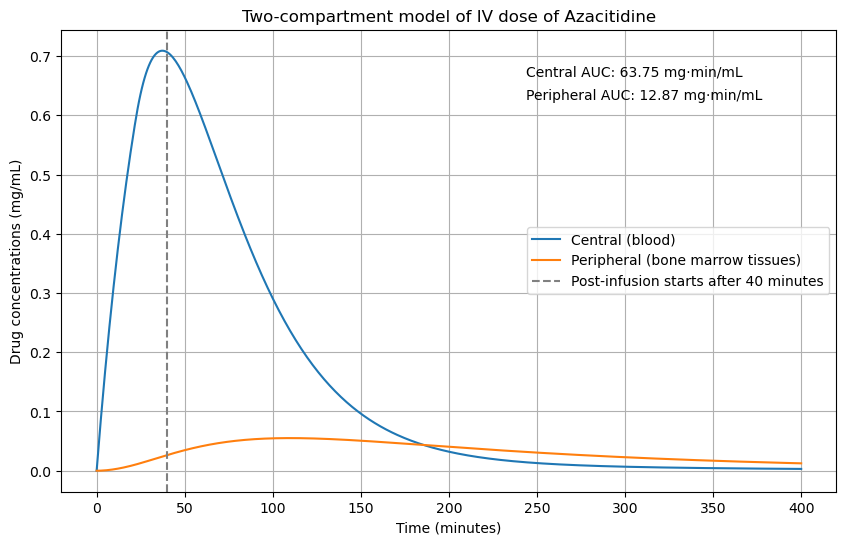

In [41]:
from scipy.integrate import trapezoid 
import numpy as np 
from scipy.integrate import odeint
import matplotlib.pyplot as plt 

#initialize the parameters 
R0 = 2.863  #171.35 mL/hr  (rate of infusion)
V1 = 76      #L (total volume of distribution of both compartments, so like blood + tissues) 

k10 = 0.03151 #1.8902 #hr  #0.03151 in minutes   #1/hr (elimination rate)
k12 = 0.00149  #0.0892  #assumption that the k12 is leaving so clearance into the peripheral to get the numbers - 
k21 = 0.00641   #0.3847 (Q/volume of the intercompartment model)

decay_rate = 0.03151 #also known as the elimination constant
decay_start = 22 #time when decay begins 

infusion_rates = [] 

#define the function
def two_compart(y, t):
    C1, C2 = y 

    if t<= decay_start: 
        infusion = k0/V1 
    else: 
        time_since_decay = t - decay_start
        infusion = (k0/V1) * np.exp(-decay_rate * time_since_decay)

        infusion_rates.append(infusion)
        
    #the drug never stops infusing, like eventually it should decrease (post infusion) 
    dC1dt = infusion - (k10 + k12)*C1 + k21*C2 
    #dC1dt = (k0/V1) - (k10 + k12)*C1 + k21*C2
    dC2dt = k12*C1 - k21*C2 

    return [dC1dt, dC2dt] 

#initial concentrations 
y0 = [0, 0] 

#time for it to be modelled in
#t_span = (0, 100) 
#t_eval = np.linspace(0, 100, 500) 

t = np.linspace(0, 400, 500) 

#Solve ODE
solution = odeint(two_compart, y0, t) 

C1 = solution[:, 0] 
C2 = solution[:, 1] 

#Trapezoidal rule to find the area under the curve (numerical integration) 
auc_central = trapezoid(C1, t)     #np.trapezoid(C1, t) 
auc_peripheral = trapezoid(C2, t)         #np.trapezoid(C2, t) 

#Plot 
plt.figure(figsize=(10, 6))
plt.plot(t, C1, label = "Central (blood)") 
plt.plot(t, C2, label = "Peripheral (bone marrow tissues)") 

plt.axvline(x=40, color='0.5', linestyle='--', label='Post-infusion starts after 40 minutes')
plt.xlabel("Time (minutes)") 
plt.ylabel("Drug concentrations (mg/mL)") 
plt.grid(True) 
plt.title("Two-compartment model of IV dose of Azacitidine") 
plt.annotate(f"Central AUC: {auc_central:.2f} mg·min/mL", xy=(0.6, 0.9), xycoords='axes fraction')
plt.annotate(f"Peripheral AUC: {auc_peripheral:.2f} mg·min/mL", xy=(0.6, 0.85), xycoords='axes fraction')
             
plt.legend()
plt.show() 

#AUC units: mg * min/mL 

In [43]:
print(f"Area under the curve (AUC) for the central compartment (blood):{auc_central: .2f} mg·min/mL") 
print(f"Area under the curve (AUC) for the peripheral compartment (bone marrow tissues): {auc_peripheral:.2f} mg·min/mL") 

Area under the curve (AUC) for the central compartment (blood): 63.75 mg·min/mL
Area under the curve (AUC) for the peripheral compartment (bone marrow tissues): 12.87 mg·min/mL
